In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sl

# Car Price Prediction Model


In [4]:
df=pd.read_csv('F:\Python Exercises from DataClub\Car Price Prediction/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
# data cleaning
df.columns=df.columns.str.lower().str.replace(' ','_')
df.dtypes
strings=list(df.dtypes[df.dtypes=='object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [6]:
# still data cleaning
for col in strings:
    df[col]=df[col].str.lower().str.replace(' ','_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [7]:
# still data cleaning
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()
    

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

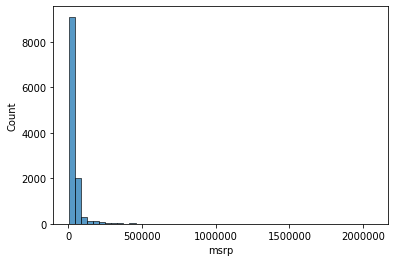

In [9]:
# That is a long-tail distribution
sns.histplot(df.msrp, bins=50)

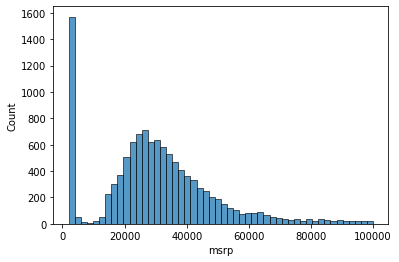

In [10]:
# We can zoom in a bit by using the below command
sns.histplot(df.msrp[df.msrp<100000], bins=50)

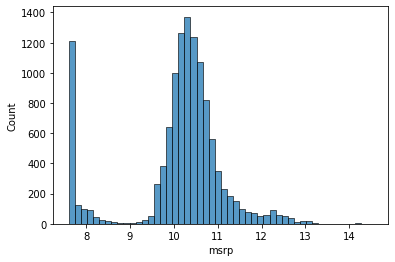

In [11]:
# The thing we do is to apply logorithm on it.
# Numpy function below add 1 for us
# This sort of resembles like Normal distribution
# The model does quite well on this kind of distribution
price_logs=np.log1p(df.msrp)
sns.histplot(price_logs, bins=50)

In [12]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setting up a validation framework

In [13]:
# Training 60%, Validation 20%, Test 20%
n=len(df)

n_val =int(n*0.2)
n_test= int(n*0.2)
n_training= n-n_val-n_test

In [14]:
print(n)
n_training,n_val, n_test

11914


(7150, 2382, 2382)

In [15]:
idx=np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

In [16]:
# df.iloc shows us the records from where we started and n-1 where we ended
df_train= df.iloc[idx[:n_training]]
df_val=df.iloc[idx[n_training:n_training+n_val]]
df_test=df.iloc[idx[n_training+n_val:]]

In [17]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [18]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
752,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
3137,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


In [19]:
y_train=np.log1p(df_train.msrp.values)
y_val=np.log1p(df_val.msrp.values)
y_test=np.log1p(df_test.msrp.values)

In [20]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [21]:
len(y_train)

7150

### Linear Regression

In [22]:
## g is the model, in this case linear regression, X is a matrix.
## the task is to try to use this model to get somewhere near the actual price 'y' which is the target price.
## g(x_i) \approx y_i, x_i are the features
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                    453
engine_cylinders                              12
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                                2
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 7557, dtype: object

In [23]:
xi=[453,11,86]
w0=7.17
w=[0.01, 0.04, 0.002]

In [24]:
## Linear Regression is basically measrured as:
## y_i=w_0+\sum_{j=0}^n w_j x_{ij}
## this should be true: w_0+\sum_{j=0}^n w_j x_{ij} \approx \hat{y}
## 
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range(n):
        pred=pred+w[j]*xi[j]
        
    return pred

In [25]:
linear_regression(xi)

12.312

In [26]:
## Since we used log1p over this xi, we need to now transfer it back by taking an exponential of this price 
np.expm1(12.312)

222347.2221101062

In [27]:
def dot(xi,w):
    n=len(xi)
    res=0.0
    for j in range(n):
        res=res+xi[j]*w[j]
    return res

In [28]:
def linear_regression(xi):
    return w0+dot(xi,w)

In [29]:
w_new=[w0]+w
print(w_new)

[7.17, 0.01, 0.04, 0.002]


In [30]:
def linear_regression(xi):
    xi=[1]+xi
    w_new=[w0]+w
    return dot(xi,w_new)

In [31]:
linear_regression(xi)

12.312

In [39]:
import numpy as np

x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x3 = [1, 453, 11, 86]

X = np.array([x1, x2, x3])
# X = [x1,x2,x3]

print(type(X))

<class 'numpy.ndarray'>


In [44]:
def linear_regression(X):
    w_new=[w0]+w
    return X.dot(w_new)

In [45]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [ ]:
# g(X)=X_W \approx y here X_W is the matrix with weights vector
# There exist an X^-1 that we need to multiply on both sides, but an inverse has to exist for that
# and that will only exist if its a square matrix
# we can get the approximate solution by multiplying X^T with it
# so now it becomes  X^T X_W=X^T y
# X^T X_W is called Gram Matrix
# The dimension of this is (n+1)x(n+1)
# We do next (X^T X_W)^-1 X^T X_W=(X^T X)^-1 X^T y so that gets us an identity matrix
# That gets us I_W=(X^T X)^-1 X^T y
#

